# A exploratoring data analysis on the data of Suicide Attempts in Shandong, China
The main aim of this project is to do the analysis on various features contributing or reanable for suicidal attempts.


The Data Analysis (EDA) includes the below points:

*   Knowing dataset and its data.
*   Finding missing Values
*   Descriptive Statistics, unique values
*   Checking Numerical Variables
*   Identify shape
*   Plotting features against target
*   Outliers
*   Correlation between variables

In [ ]:
#importing python libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
#importing csv file
dataset = pd.read_csv('/content/SuicideChina.csv')

In [ ]:
# print shape of dataset with rows and columns
print(dataset.shape)

(2602, 12)


In [ ]:
#Displaying the data from csv file imported
dataset.head()

,Unnamed: 0,Person_ID,Hospitalised,Died,Urban,Year,Month,Sex,Age,Education,Occupation,method
0,1.0,1.0,yes,no,no,2010,12.0,female,39.0,Secondary,household,Other poison
1,2.0,2.0,no,yes,no,2009,3.0,male,83.0,primary,farming,Hanging
2,3.0,3.0,no,yes,no,2010,2.0,male,60.0,primary,farming,Hanging
3,4.0,4.0,no,yes,no,2011,1.0,male,73.0,primary,farming,Hanging
4,5.0,5.0,yes,no,no,2009,8.0,male,51.0,Secondary,farming,Pesticide


In [ ]:
#displaying the information of the file like column_names ,its data type, etc, to get familiarized with content of the dataset:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2602 entries, 0 to 2601
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2595 non-null   float64
 1   Person_ID     2595 non-null   float64
 2   Hospitalised  2602 non-null   object 
 3   Died          2602 non-null   object 
 4   Urban         2602 non-null   object 
 5   Year          2602 non-null   int64  
 6   Month         2580 non-null   float64
 7   Sex           2602 non-null   object 
 8   Age           2579 non-null   float64
 9   Education     2602 non-null   object 
 10  Occupation    2602 non-null   object 
 11  method        2602 non-null   object 
dtypes: float64(4), int64(1), object(7)
memory usage: 244.1+ KB


Descriptive Statistics

In [ ]:
dataset.describe()

,Unnamed: 0,Person_ID,Year,Month,Age
count,2595.000000,2595.000000,2602.000000,2580.000000,2579.000000
mean,1298.000000,1298.000000,2010.046118,6.278295,52.763474
std,749.256298,749.256298,0.791260,3.212772,19.847926
min,1.000000,1.000000,2009.000000,1.000000,12.000000
25%,649.500000,649.500000,2009.000000,4.000000,37.000000
50%,1298.000000,1298.000000,2010.000000,6.000000,53.000000
75%,1946.500000,1946.500000,2011.000000,9.000000,69.000000
max,2595.000000,2595.000000,2011.000000,12.000000,100.000000


Using this, we can see a bit of detailed statistics such as mean age of person commiting suicide in chine is 52, etc.

Number of unique values for each column

In [ ]:
unique_val= dataset.nunique()
print("Uniques values in each column are:")
print(unique_val)

Uniques values in each column are:
Unnamed: 0      2595
Person_ID       2595
Hospitalised       2
Died               2
Urban              3
Year               3
Month             12
Sex                2
Age               87
Education          5
Occupation        10
method             9
dtype: int64


Finding the missing values of the dataset :
---



In [ ]:
## displaying the list of features whose values are missing:
dataset.isnull().sum()

Unnamed: 0       7
Person_ID        7
Hospitalised     0
Died             0
Urban            0
Year             0
Month           22
Sex              0
Age             23
Education        0
Occupation       0
method           0
dtype: int64

Our data set has few missing data, which we will handle to get 0 null values.

---



In [ ]:
d=dataset.copy()
d.head()

,Unnamed: 0,Person_ID,Hospitalised,Died,Urban,Year,Month,Sex,Age,Education,Occupation,method
0,1.0,1.0,yes,no,no,2010,12.0,female,39.0,Secondary,household,Other poison
1,2.0,2.0,no,yes,no,2009,3.0,male,83.0,primary,farming,Hanging
2,3.0,3.0,no,yes,no,2010,2.0,male,60.0,primary,farming,Hanging
3,4.0,4.0,no,yes,no,2011,1.0,male,73.0,primary,farming,Hanging
4,5.0,5.0,yes,no,no,2009,8.0,male,51.0,Secondary,farming,Pesticide


In [ ]:
# dropping insignificant columns:
d = d.drop(d.columns[[0,1]],axis = 1)
d.head()

,Hospitalised,Died,Urban,Year,Month,Sex,Age,Education,Occupation,method
0,yes,no,no,2010,12.0,female,39.0,Secondary,household,Other poison
1,no,yes,no,2009,3.0,male,83.0,primary,farming,Hanging
2,no,yes,no,2010,2.0,male,60.0,primary,farming,Hanging
3,no,yes,no,2011,1.0,male,73.0,primary,farming,Hanging
4,yes,no,no,2009,8.0,male,51.0,Secondary,farming,Pesticide


In [ ]:
# checking missing values now:
d.isnull().sum()

Hospitalised     0
Died             0
Urban            0
Year             0
Month           22
Sex              0
Age             23
Education        0
Occupation       0
method           0
dtype: int64

Filling missing values of 'Month' coulmn with the value before it and most frequent value

In [ ]:
d['Month']=d['Month'].fillna(method='bfill')#filled with value before it
d['Month'] = d['Month']. fillna(d['Month']. value_counts(). index[0])#most frequent value

Filling missing values of 'Age' coulmn with mean value of the column

In [ ]:
age_mean = d['Age'].mean()
d['Age'] = d['Age'].fillna(age_mean)

Missing value check:

In [ ]:
d.isnull().sum()

Hospitalised    0
Died            0
Urban           0
Year            0
Month           0
Sex             0
Age             0
Education       0
Occupation      0
method          0
dtype: int64

In [ ]:
print("urban:", dataset['Urban'].value_counts().unknown)
print("Education:", dataset['Education'].value_counts().unknown)

urban: 81
Education: 80


Though, there are no missing values but we have 80 and 81 columns in "education" and "urban" where values are 'unkown'.

Numerical Variables:

In [ ]:
# creating a list of numerical variables:
num_features = [f for f in dataset.columns if dataset[f].dtypes != 'O']
print('Number of numerical variables in the dataset: ', len(num_features))
dataset[num_features].head()

Number of numerical variables in the dataset:  5


,Unnamed: 0,Person_ID,Year,Month,Age
0,1.0,1.0,2010,12.0,39.0
1,2.0,2.0,2009,3.0,83.0
2,3.0,3.0,2010,2.0,60.0
3,4.0,4.0,2011,1.0,73.0
4,5.0,5.0,2009,8.0,51.0


We have 5 numerical columns in the dataset with values. Out of which first 2 columns do not provide significant for information.

In [ ]:
#creating index for rows of died people information
index= d['Died']=='yes'

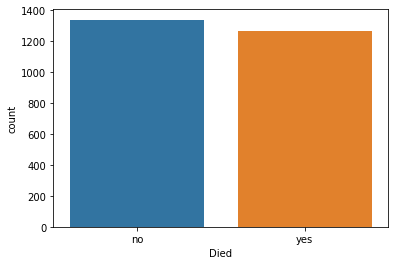

In [ ]:
sns.countplot(x='Died', data=d)

Here we can see that there is no major skewness in our target variable, which may impact during prediction model.

#Categorical and Numerical feature plots:

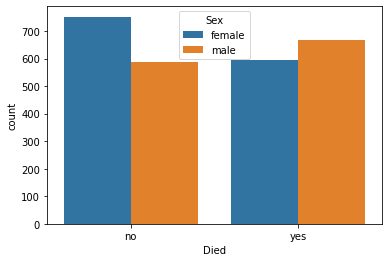

In [ ]:
sns.countplot(x='Died', hue='Sex', data=d)

The plot says that more males have died post the suicide attempts as compared to females.

Text(0, 0.5, 'Death Count')

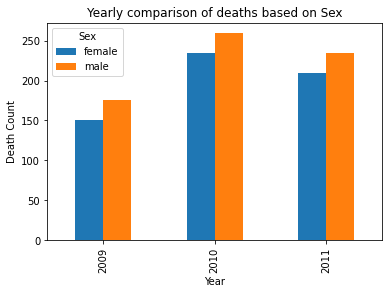

In [ ]:
#Yearly comparison of deaths based on Sex
a=d[index].groupby('Year').Sex.value_counts().unstack()
a.plot.bar(title="Yearly comparison of deaths based on Sex")
plt.xlabel('Year')
plt.ylabel('Death Count')

Here, we got to know that number of suicides increased drastically after 2009  and highest in 2010, then gradually decreasing toward 2011. Throughout 3 years of data, male suicides are more.

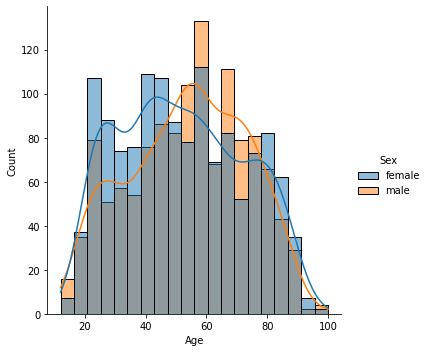

In [ ]:
sns.displot(x='Age', hue='Sex',data=d, kde=True)

The age group of 40-60 commits more suicide. The graph shows female in their 40's (and also 30's) and males in their 60's and 70's have made more suicidal attempts.

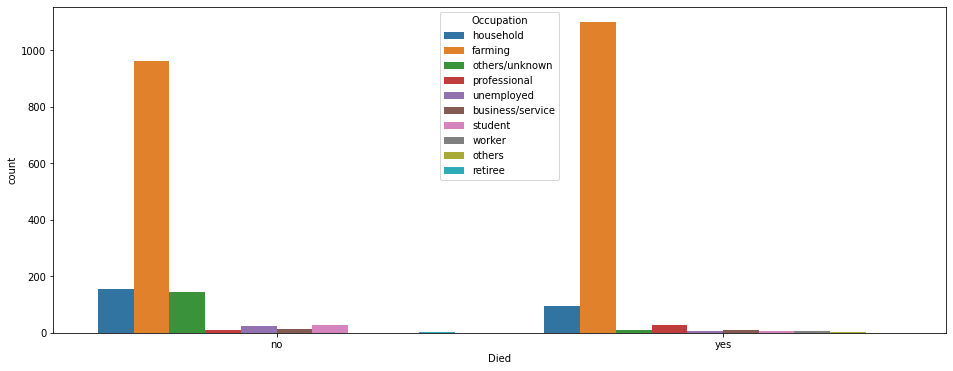

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Died', hue='Occupation', data=d)

Here we interpreted that people with occupation as 'farming' have suicided all along the time. And homemaker females have went through suicides too. Though the number of failure in attempts in suicide is same in these respective occupations.

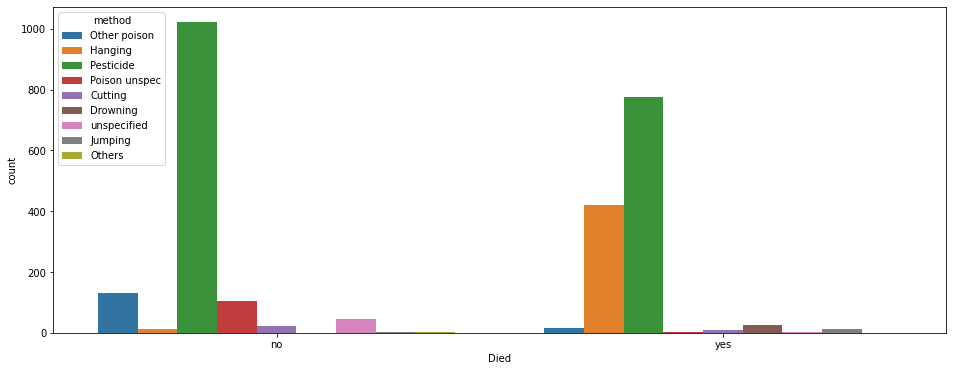

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Died', hue='method', data=d)

The chart shows that 'pesticides' is used more for suicidal attempts which basically belong to farming occupation. And 'hanging' is the second method to committ suicide which belong category of people with occupation 'houshold' and 'farming' occuring deaths.

Text(0, 0.5, 'Death Count')

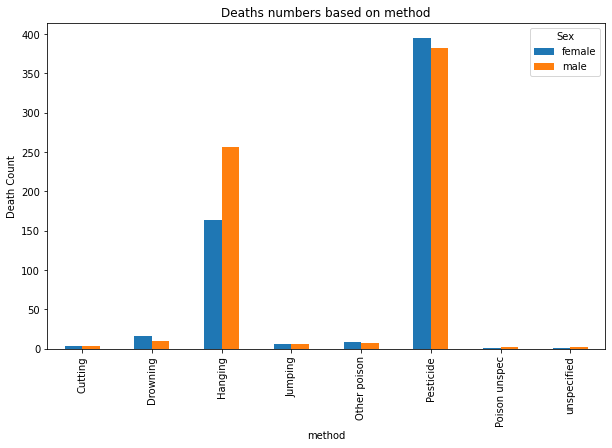

In [ ]:
#comparison of deaths based on method of dying
a=d[index].groupby('method').Sex.value_counts().unstack()
a.plot.bar(figsize=(10,6),title='Deaths numbers based on method')
plt.xlabel('method')
plt.ylabel('Death Count')

This graph more emphasizes on previous analysis. Here we are analyzing that if male or females are more in particular method of dying.

Text(0, 0.5, 'Death Count')

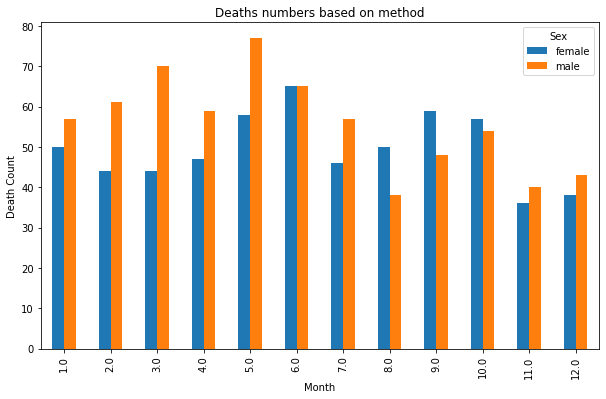

In [ ]:
#deaths numbers based on months
a=d[index].groupby('Month').Sex.value_counts().unstack()
a.plot.bar(figsize=(10,6),title='Deaths numbers based on method')
plt.xlabel('Month')
plt.ylabel('Death Count')

The graph shows that males have committed more suicide during spring and summer, whereas females have committed more suicides during winters. Which describes that the agriculture period is march to may, and due to tension male farmers suicide more due to various reasons. And during winters females have committed more suicides , the reason would me more male staying home during winters would increase their tensions.

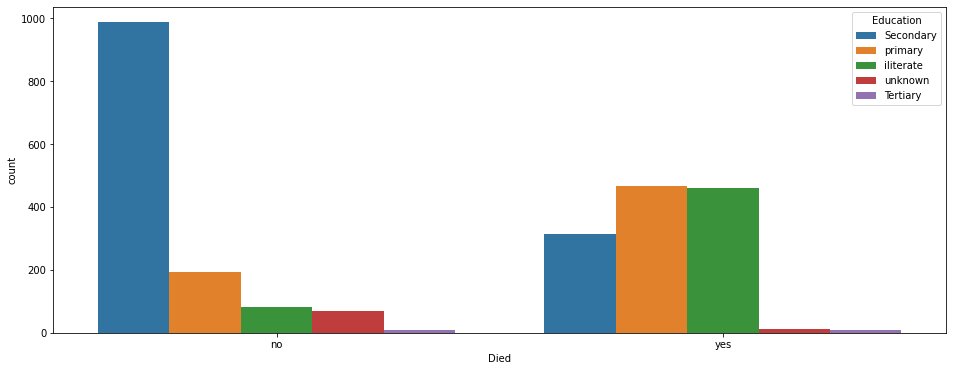

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Died', hue='Education', data=d)

Graph shows that people with 'tertiary' category in their education donot commit suicide as compared to others, while while secondary primary and iliterates have more numbers in suicidal attempts.

Text(0, 0.5, 'Death Count')

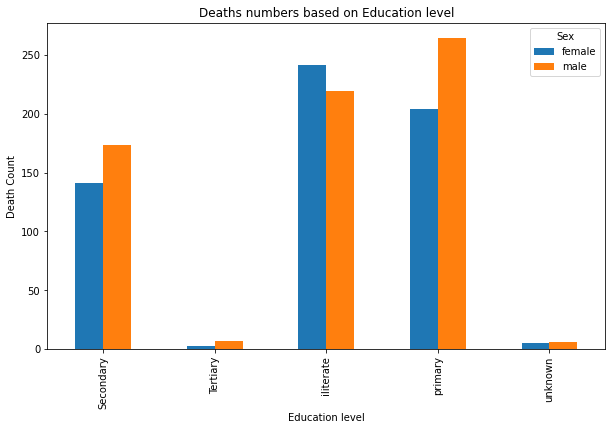

In [ ]:
#deaths numbers based on Education level
a=d[index].groupby('Education').Sex.value_counts().unstack()
a.plot.bar(figsize=(10,6),title='Deaths numbers based on Education level')
plt.xlabel('Education level')
plt.ylabel('Death Count')

With reference to previous grapg, checking the male to female death ratio on the basis of education level.

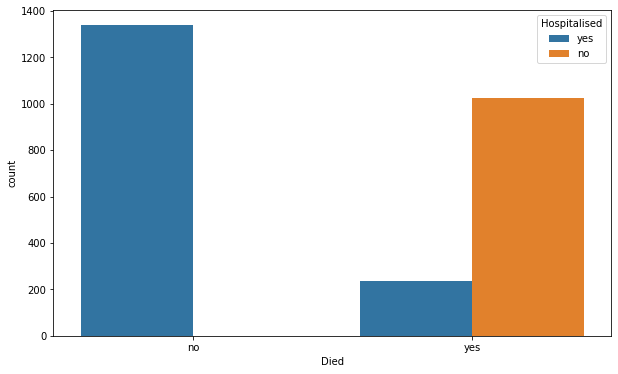

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x='Died', hue='Hospitalised', data=d)

This plot shows that there are few people who were hospitalized and still died. But those who were not hospitalized, their numbers are more in death section.

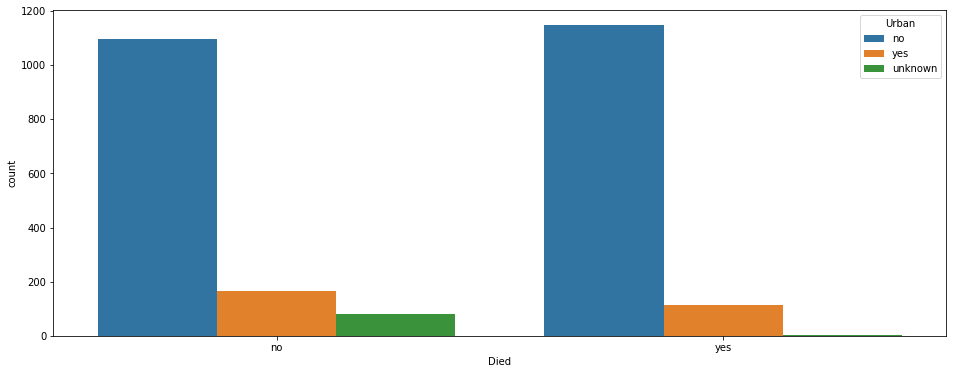

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Died', hue='Urban', data=d)

Most of the people who died were non-urbans.

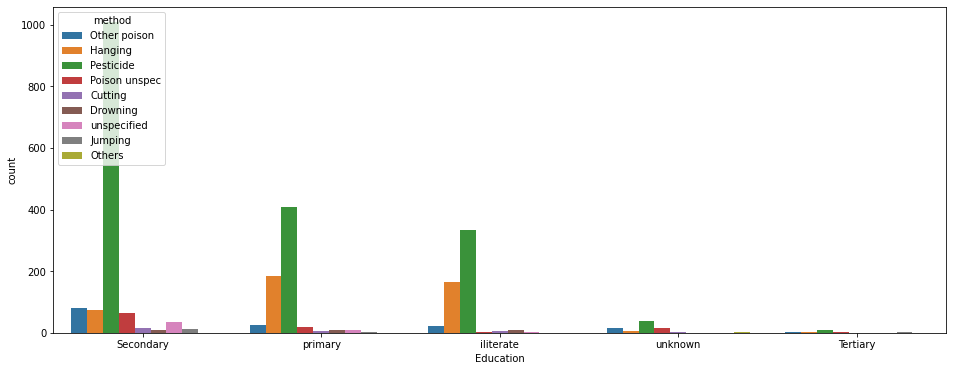

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Education', hue='method', data=d)

The graph confirms us that, people have committed suicides more by using pesticides or hanging them themselves in the first three education level.

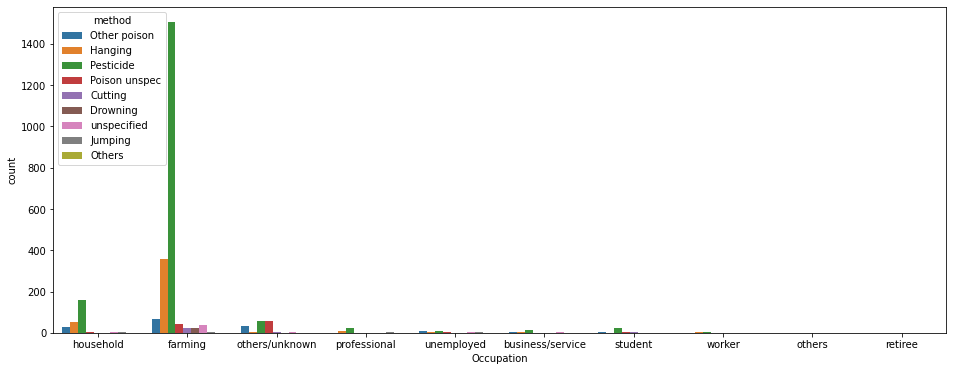

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.countplot(x='Occupation', hue='method', data=d)

With respect to previous graph and this graph, we can see that people with occupation as "farming" commits more suicides using pesticides or sometimes by hanging themselves and there is also significant number suicides in "household" category with same method of commiting suicide.

Text(0, 0.5, 'Death Count')

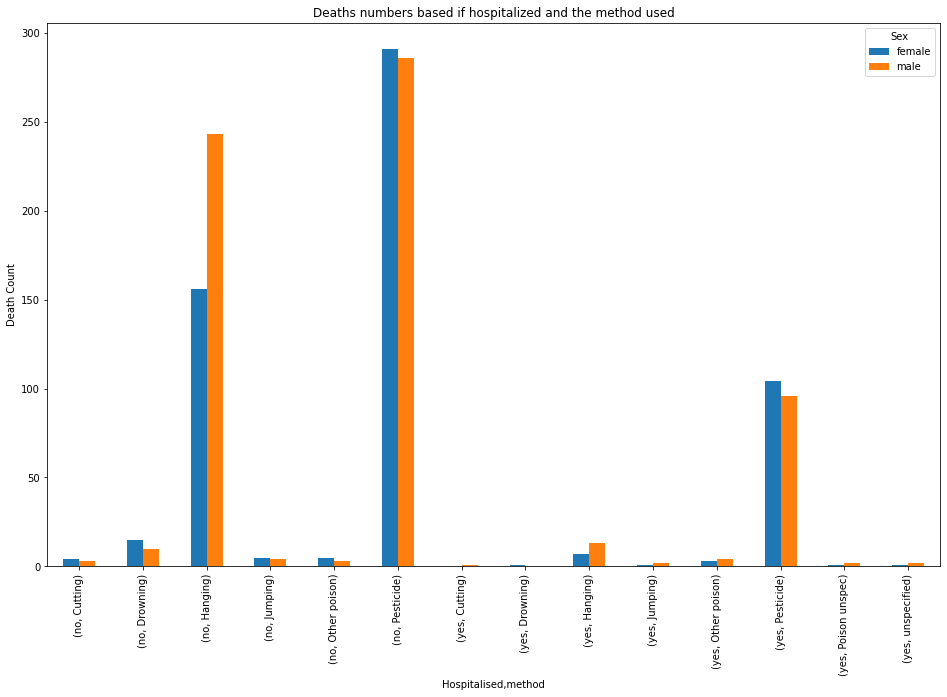

In [ ]:
#deaths numbers based on Hospitalised','method
a=d[index].groupby(['Hospitalised','method']).Sex.value_counts().unstack()
a.plot.bar(figsize=(16,10),title='Deaths numbers based if hospitalized and the method used')
plt.xlabel('Hospitalised,method')
plt.ylabel('Death Count')

This graph shows that, people who where not hospitalized after attempts of suicide have died more, there would be reasons in the case of 'hanging' that the help might have not received on time. And pesticides are more hazardous and hence people use them to end their life full and final.

Outliers:

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


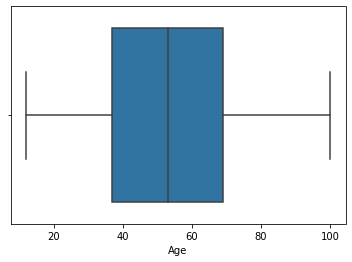

In [ ]:
sns.boxplot(dataset['Age'])

There are no outiers present in this only numerical column'Age' with significant information.

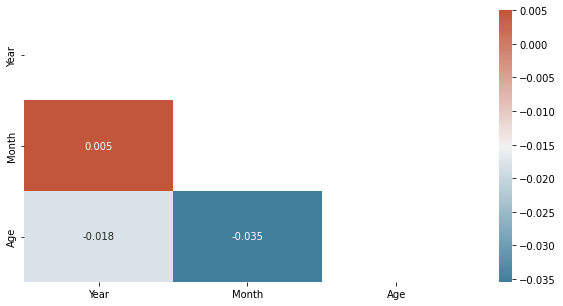

In [ ]:
# plotting heat map to find the correlation between different variables
corr = d.corr()
f, ax = plt.subplots(figsize=(10, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

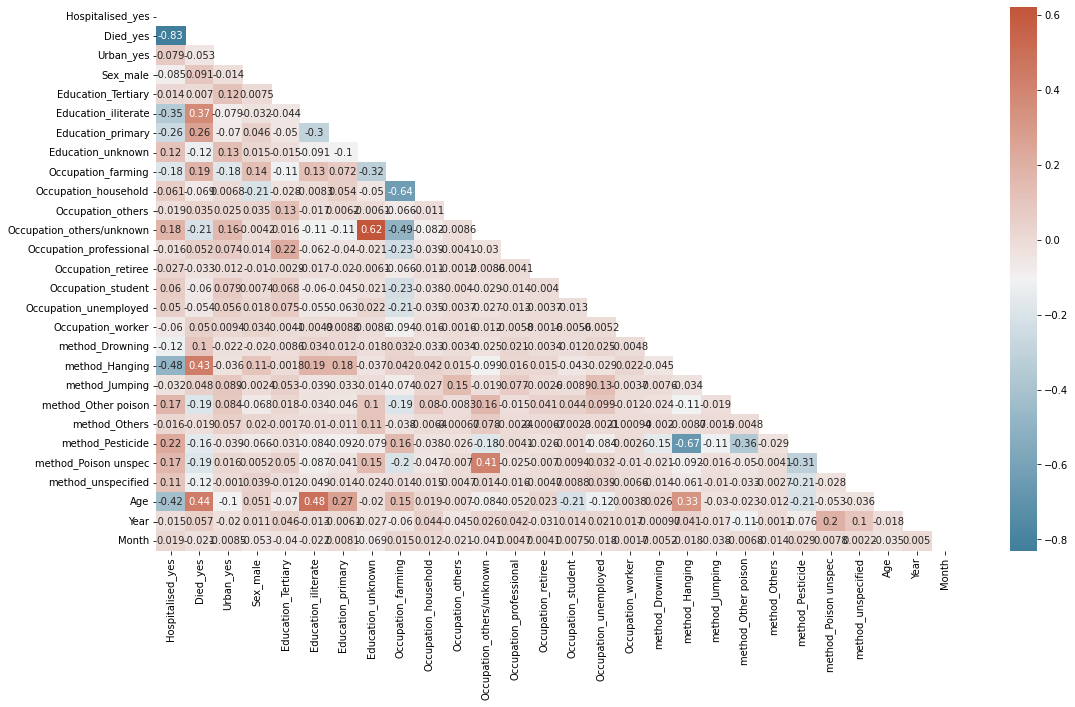

In [ ]:
# plotting heat map to find the correlation between different variables
corr = ds.corr()
f, ax = plt.subplots(figsize=(18, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, annot=True, mask = mask, cmap=cmap)

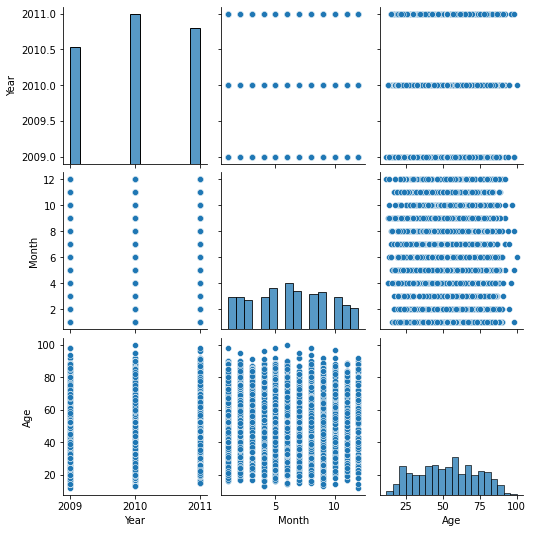

In [ ]:
#pair plot
sns.pairplot(d)
plt.show()


Conclusion:
1. The age group of people 40-60 have commited more suicide.
2. The occupation 'farming' is not more supported in the region of china. The homemakers are also seen with difficulties in living a good life.
3. The less educated people which intern are farmers and homemakers are effected more.
4. The people hospitalized died more who committed suicide using pesticides or hanging themselves.

#Feature Engineering

We have replaced all the missing values in previous part. But as we have 'unknown' values in "urban" column, we will replace them with frequently occuring value/data of the column.


In [ ]:
ds=d.copy()

In [ ]:
#replacing 'unknown' values in "urban" column with 'no':
ds['Urban'] = ds['Urban'].replace('unknown','no')

One-Hot Encoding:

To build machine learning model, categorical fields are needed to be converted to 1's and 0's for better output.

In [ ]:
ds.head()

,Hospitalised,Died,Urban,Year,Month,Sex,Age,Education,Occupation,method
0,yes,no,no,2010,12.0,female,39.0,Secondary,household,Other poison
1,no,yes,no,2009,3.0,male,83.0,primary,farming,Hanging
2,no,yes,no,2010,2.0,male,60.0,primary,farming,Hanging
3,no,yes,no,2011,1.0,male,73.0,primary,farming,Hanging
4,yes,no,no,2009,8.0,male,51.0,Secondary,farming,Pesticide


In [ ]:
colz=[ds.columns]
#performing OHE on columns, merging the new column with the sub dataset and then drop the old column:
for i in colz:
  ds= pd.concat([ds, pd.get_dummies(ds[i], drop_first=True)], axis=1).drop(i, axis=1)
ds.head()

,Hospitalised_yes,Died_yes,Urban_yes,Sex_male,Education_Tertiary,Education_iliterate,Education_primary,Education_unknown,Occupation_farming,Occupation_household,...,Occupation_unemployed,Occupation_worker,method_Drowning,method_Hanging,method_Jumping,method_Other poison,method_Others,method_Pesticide,method_Poison unspec,method_unspecified
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,0,1,0,1,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,0,1,0,1,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
3,0,1,0,1,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
ds = pd.concat([ds, d['Age'], d['Year'],d['Month']], axis=1)
ds.head()

,Hospitalised_yes,Died_yes,Urban_yes,Sex_male,Education_Tertiary,Education_iliterate,Education_primary,Education_unknown,Occupation_farming,Occupation_household,...,method_Hanging,method_Jumping,method_Other poison,method_Others,method_Pesticide,method_Poison unspec,method_unspecified,Age,Year,Month
0,1,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,39.0,2010,12.0
1,0,1,0,1,0,0,1,0,1,0,...,1,0,0,0,0,0,0,83.0,2009,3.0
2,0,1,0,1,0,0,1,0,1,0,...,1,0,0,0,0,0,0,60.0,2010,2.0
3,0,1,0,1,0,0,1,0,1,0,...,1,0,0,0,0,0,0,73.0,2011,1.0
4,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,1,0,0,51.0,2009,8.0


In [ ]:
#checking if all the categorical columns are transformed using OHE:
ds.nunique()

Hospitalised_yes              2
Died_yes                      2
Urban_yes                     2
Sex_male                      2
Education_Tertiary            2
Education_iliterate           2
Education_primary             2
Education_unknown             2
Occupation_farming            2
Occupation_household          2
Occupation_others             2
Occupation_others/unknown     2
Occupation_professional       2
Occupation_retiree            2
Occupation_student            2
Occupation_unemployed         2
Occupation_worker             2
method_Drowning               2
method_Hanging                2
method_Jumping                2
method_Other poison           2
method_Others                 2
method_Pesticide              2
method_Poison unspec          2
method_unspecified            2
Age                          88
Year                          3
Month                        12
dtype: int64

#Preparing model:
1. Importing libraries
2. Splitting dataset for training and testing
3. Standardizing the data

Splitting the dataset:

In [ ]:
#features of model:
x=ds.drop('Died_yes',axis=1)
y=ds['Died_yes']

# setting data for training and testing:
from sklearn.model_selection import train_test_split

# setting test data size 20%
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size= 0.20, random_state=6)

Standardizing the data

In [ ]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.fit_transform(x_test)

### The Logistic Regression model
1. Importing model from library and creating model instance
2. Model fitting
3. Predictions
4. Feature importance
5. Confusion Matrix
6. Report(Precision, Recall, F1-score, Accuracy)
7. AUC


In [ ]:
from sklearn.linear_model import LogisticRegression

#creating model instance
logreg = LogisticRegression(random_state=6)

# fitting the model with data
logreg.fit(x_train, y_train)

LogisticRegression(random_state=6)

Predictions

In [ ]:
y_pred_log = logreg.predict(x_test)
res_log = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred_log})
res_log

,Actual,Predicted
342,0,0
733,1,1
2322,1,1
166,1,0
1192,1,1
...,...,...
1370,0,0
2226,0,0
2520,0,0
24,1,1


Feature Importance:

In [ ]:
#finding weights of the coefficients and intercept:
imp = logreg.coef_[0]

for i,j in enumerate(imp):
    print('Feature: %0d, Score: %.5f' % (i,j))

for k in enumerate(x.columns):
    print(k)


print('')
print(f'Intercept: {logreg.intercept_}')

Feature: 0, Score: -3.47327
Feature: 1, Score: 0.10641
Feature: 2, Score: 0.15480
Feature: 3, Score: 0.09768
Feature: 4, Score: 0.70134
Feature: 5, Score: 0.49085
Feature: 6, Score: 0.23926
Feature: 7, Score: -0.35923
Feature: 8, Score: -0.52785
Feature: 9, Score: 0.01463
Feature: 10, Score: -0.64164
Feature: 11, Score: 0.05350
Feature: 12, Score: -0.18140
Feature: 13, Score: -0.03269
Feature: 14, Score: -0.07551
Feature: 15, Score: 0.05352
Feature: 16, Score: 0.18282
Feature: 17, Score: 1.01961
Feature: 18, Score: 0.17782
Feature: 19, Score: -0.13316
Feature: 20, Score: -0.08248
Feature: 21, Score: 0.16369
Feature: 22, Score: -0.28878
Feature: 23, Score: -0.13052
Feature: 24, Score: 0.32101
Feature: 25, Score: 0.47078
Feature: 26, Score: -0.01812
(0, 'Hospitalised_yes')
(1, 'Urban_yes')
(2, 'Sex_male')
(3, 'Education_Tertiary')
(4, 'Education_iliterate')
(5, 'Education_primary')
(6, 'Education_unknown')
(7, 'Occupation_farming')
(8, 'Occupation_household')
(9, 'Occupation_others')
(10

Plotting the feature importance on basis of the above coefficients:

In [ ]:
f_imp = abs(logreg.coef_[0])
f_imp = 100.0 * (f_imp / f_imp.max())
sorted_idx = np.argsort(f_imp)
pos = np.arange(sorted_idx.shape[0]) + .5

featfig = plt.figure(figsize=(12, 8))
featax = featfig.add_subplot(1, 1, 1)
featax.barh(pos, f_imp[sorted_idx], align='center')
featax.set_yticks(pos)
featax.set_yticklabels(np.array(x.columns)[sorted_idx], fontsize=8)
featax.set_xlabel('Relative Feature Importance')

plt.tight_layout()
plt.show()

Model Evaluation using Confusion Matrix:

Text(0.5, 15.0, 'Predicted label')

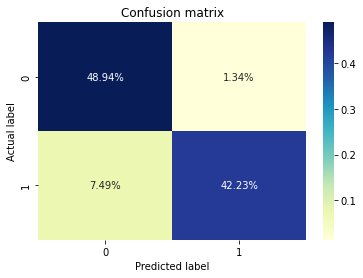

In [ ]:
from sklearn import metrics
cm_log = metrics.confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log/np.sum(cm_log), annot=True, fmt='.2%', cmap='YlGnBu')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

Confusion matrix shows that the actual negative values(false negative are predicted 48.94% correctly and actual positive values(true positive) are predicted 42.23% correctly.

On the other hand when the value was actual negative but the model predicted it to positive, this happened for 1.34% and when the actual value was positive but the model predicted to be negative for 7.49%.

 Report (Precision, Recall, F1-score, Accuracy)

In [ ]:
from sklearn.metrics import classification_report
target_names = ['Died', 'Alive']
print(classification_report(y_test, y_pred_log, target_names=target_names))

              precision    recall  f1-score   support

        Died       0.87      0.97      0.92       262
       Alive       0.97      0.85      0.91       259

    accuracy                           0.91       521
   macro avg       0.92      0.91      0.91       521
weighted avg       0.92      0.91      0.91       521



Accuracy of the model is 91% according to F1-score.

Precision: Model did predict 87% correctly the people died who actually died. And 97% correctly predicted as alive who actually survived.

Recall : This measures how many of the survived_victims the model is able to identify. Accordingly, our model identified 85% of them.



AUC

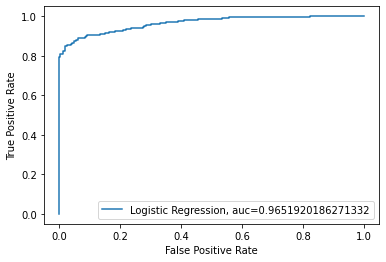

In [ ]:
y_pred_proba = logreg.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="Logistic Regression, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

#Changing test to train data ratio:

Splitting the dataset:

In [ ]:
#features of model:
x1=ds.drop('Died_yes',axis=1)
y1=ds['Died_yes']

# setting data for training and testing:
from sklearn.model_selection import train_test_split

# setting test data size 20%
x1_train, x1_test, y1_train, y1_test =train_test_split(x1,y1,test_size= 0.30, random_state=6)

In [ ]:
#Standardizing the data
from sklearn.preprocessing import StandardScaler
sc_x1 = StandardScaler()
x1_train = sc_x1.fit_transform(x1_train)
x1_test = sc_x1.fit_transform(x1_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

#creating model instance
logreg1 = LogisticRegression(random_state=6)

# fitting the model with data
logreg1.fit(x1_train, y1_train)

LogisticRegression(random_state=6)

In [ ]:
#Predictions
y1_pred = logreg1.predict(x1_test)
res1 = pd.DataFrame({'Actual' : y1_test, 'Predicted' : y1_pred})
res1

,Actual,Predicted
342,0,0
733,1,1
2322,1,1
166,1,0
1192,1,1
...,...,...
960,0,0
2453,1,1
1141,1,1
882,1,1


Text(0.5, 15.0, 'Predicted label')

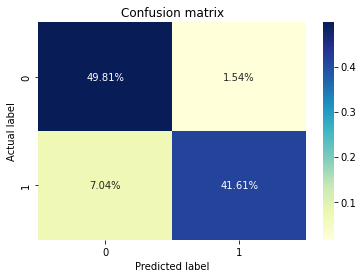

In [ ]:
#Confusion Matrix
cm_log1 = metrics.confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm_log1/np.sum(cm_log1), annot=True, fmt='.2%', cmap='YlGnBu')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

Confusion matrix shows that the actual negative values(false negative are predicted 49.81%(previosly 48.94%) correctly and actual positive values(true positive) are predicted 41.61% (previously 42.23%) correctly.

On the other hand when the value was actual negative but the model predicted it to positive, this happened for 1.54% (previously 1.34%) and when the actual value was positive but the model predicted to be negative for 7.04% (previously 7.49%).


In [ ]:
#Report(Precision, Recall, F1-score, Accuracy)
target_names = ['Died', 'Alive']
print(classification_report(y1_test, y1_pred, target_names=target_names))

              precision    recall  f1-score   support

        Died       0.88      0.97      0.92       401
       Alive       0.96      0.86      0.91       380

    accuracy                           0.91       781
   macro avg       0.92      0.91      0.91       781
weighted avg       0.92      0.91      0.91       781



Accuracy of the model is 91% according to F1-score.

Precision: Model did predict 88% correctly the people died who actually died. And 96% correctly predicted as alive who actually survived.

Recall : This measures how many of the survived_victims the model is able to identify. Accordingly, our model identified 86% of them.

### The Decision Tree Model
1. Importing model from library and creating model instance
2. Model fitting
3. Plotting clasification
4. Predictions
5. Confusion Matrix
6. Report(Precision, Recall, F1-score, Accuracy)
7. Changing the depth, checking results on decision tree model
8. AUC

In [ ]:
from sklearn import tree
#creating model instance
deci = tree.DecisionTreeClassifier(random_state=6)
#fitting model
deci.fit(x_train, y_train)

DecisionTreeClassifier(random_state=6)

Plotting clasification

[Text(0.8186898457635309, 0.9772727272727273, 'Hospitalised_yes <= -0.218\ngini = 0.499\nsamples = 2081\nvalue = [1077, 1004]'),
 Text(0.8145661344233247, 0.9318181818181818, 'gini = 0.0\nsamples = 819\nvalue = [0, 819]'),
 Text(0.8228135571037372, 0.9318181818181818, 'Education_iliterate <= 0.76\ngini = 0.25\nsamples = 1262\nvalue = [1077, 185]'),
 Text(0.7005240214239691, 0.8863636363636364, 'method_Hanging <= 0.878\ngini = 0.214\nsamples = 1156\nvalue = [1015, 141]'),
 Text(0.5659964964561855, 0.8409090909090909, 'Age <= 0.237\ngini = 0.199\nsamples = 1133\nvalue = [1006, 127]'),
 Text(0.47036283827319586, 0.7954545454545454, 'Occupation_professional <= 3.938\ngini = 0.151\nsamples = 897\nvalue = [823, 74]'),
 Text(0.3757772229381443, 0.75, 'method_Jumping <= 6.527\ngini = 0.144\nsamples = 883\nvalue = [814, 69]'),
 Text(0.3250724871134021, 0.7045454545454546, 'Year <= 0.581\ngini = 0.141\nsamples = 880\nvalue = [813, 67]'),
 Text(0.23603414948453608, 0.6590909090909091, 'Month <= 1

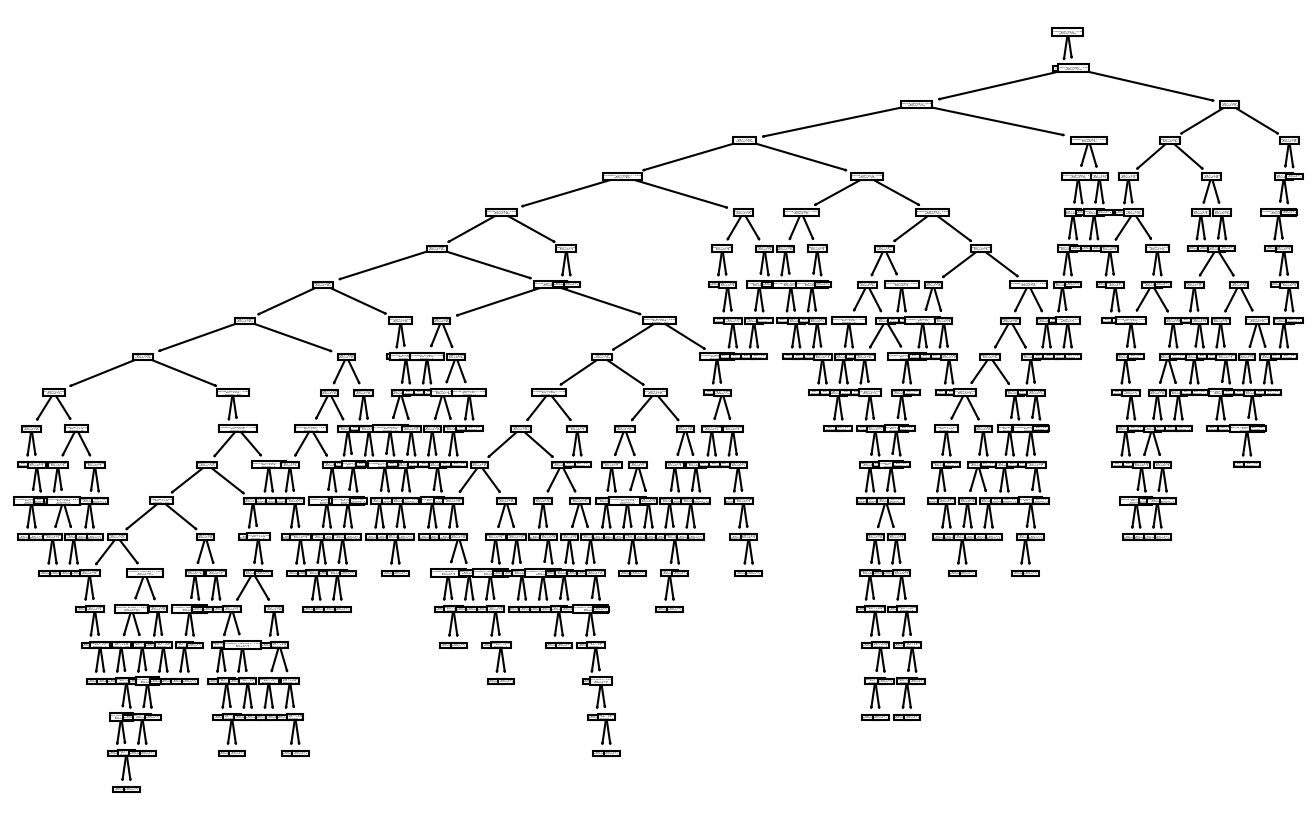

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(11,7),dpi=150)
plot_tree(deci, feature_names=x.columns)

Predictions

In [ ]:
y_pred_deci = deci.predict(x_test)
res_deci = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred_deci})
res_deci

,Actual,Predicted
342,0,0
733,1,1
2322,1,1
166,1,1
1192,1,1
...,...,...
1370,0,0
2226,0,0
2520,0,0
24,1,1


Model Evaluation using Confusion Matrix

Text(0.5, 15.0, 'Predicted label')

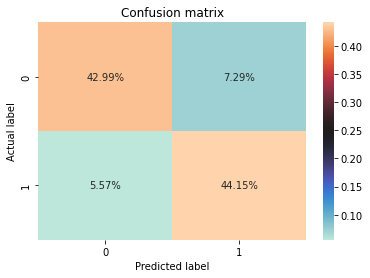

In [ ]:
cm_deci = metrics.confusion_matrix(y_test, y_pred_deci)
sns.heatmap(cm_deci/np.sum(cm_deci), annot=True, fmt='.2%', cmap='icefire')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

Confusion matrix shows that the actual negative values(false negative are predicted 42.99% correctly and actual positive values(true positive) are predicted 44.15% correctly.

On the other hand when the value was actual negative but the model predicted it to positive, this happened for 7.29% and when the actual value was positive but the model predicted to be negative for 5.57%.

Report(Precision, Recall, F1-score, Accuracy)

In [ ]:
target_names = ['Died', 'Alive']
print(classification_report(y_test, y_pred_deci, target_names=target_names))

              precision    recall  f1-score   support

        Died       0.89      0.85      0.87       262
       Alive       0.86      0.89      0.87       259

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521



Accuracy of the model is 87% according to F1-score.

Precision: Model did predict 89% correctly the people died who actually died. And 86% correctly predicted as alive who actually survived.

Recall : This measures how many of the survived_victims the model is able to identify. Accordingly, our model identified 89% of them.

Changing the depth, checking results on decision tree model

In [ ]:
deci2 = tree.DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state=6)
#fitting model
decifit=deci2.fit(x_train, y_train)

Predictions

In [ ]:
y_pred_deci2 = deci2.predict(x_test)
y_pred_deci2_train = deci2.predict(x_train)


Plotting clasification

[Text(0.4791666666666667, 0.9166666666666666, 'Hospitalised_yes <= -0.218\nentropy = 0.999\nsamples = 2081\nvalue = [1077, 1004]'),
 Text(0.4375, 0.75, 'entropy = 0.0\nsamples = 819\nvalue = [0, 819]'),
 Text(0.5208333333333334, 0.75, 'Age <= 0.003\nentropy = 0.601\nsamples = 1262\nvalue = [1077, 185]'),
 Text(0.2708333333333333, 0.5833333333333334, 'Education_iliterate <= 0.76\nentropy = 0.437\nsamples = 822\nvalue = [748, 74]'),
 Text(0.16666666666666666, 0.4166666666666667, 'Occupation_professional <= 3.938\nentropy = 0.408\nsamples = 807\nvalue = [741, 66]'),
 Text(0.08333333333333333, 0.25, 'Year <= 0.581\nentropy = 0.387\nsamples = 792\nvalue = [732, 60]'),
 Text(0.041666666666666664, 0.08333333333333333, 'entropy = 0.316\nsamples = 526\nvalue = [496, 30]'),
 Text(0.125, 0.08333333333333333, 'entropy = 0.508\nsamples = 266\nvalue = [236, 30]'),
 Text(0.25, 0.25, 'Age <= -0.801\nentropy = 0.971\nsamples = 15\nvalue = [9, 6]'),
 Text(0.20833333333333334, 0.08333333333333333, 'entro

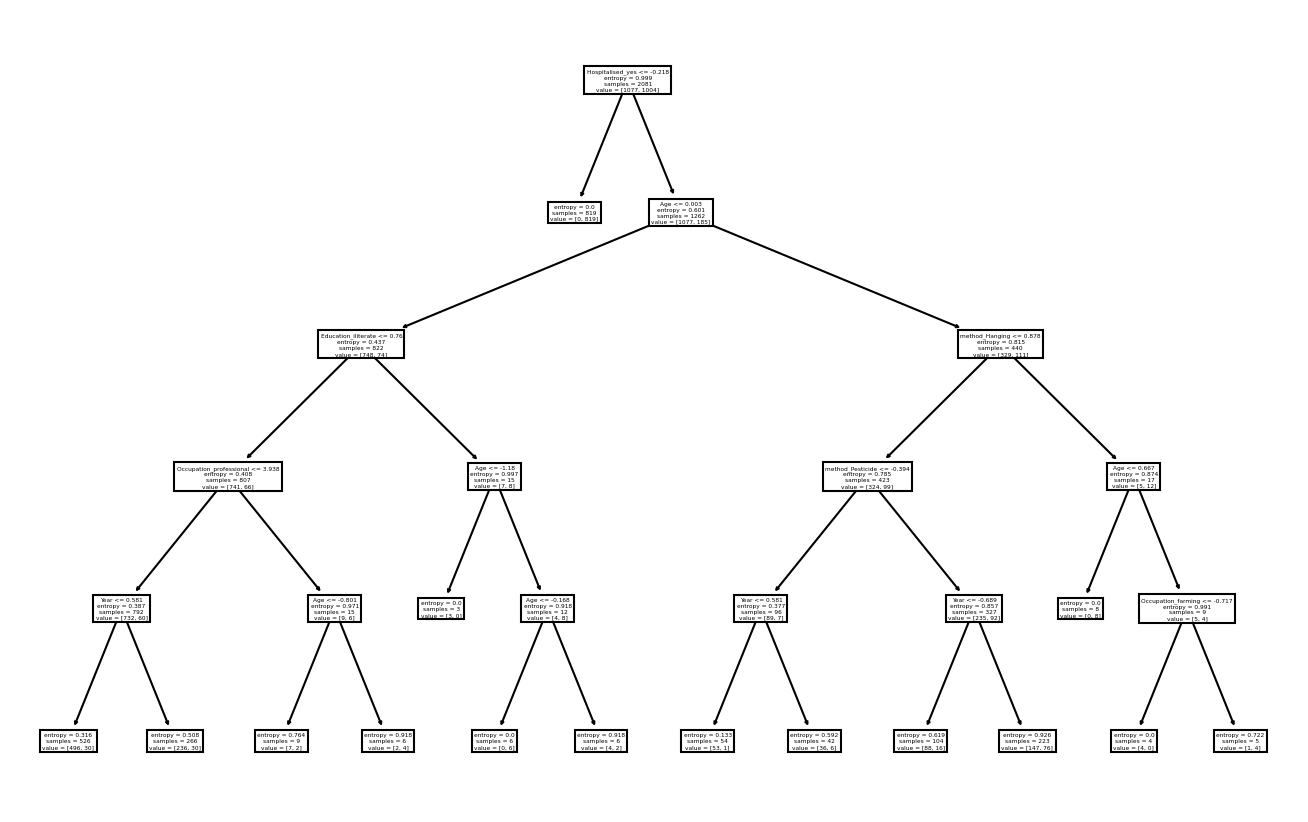

In [ ]:
plt.figure(figsize=(11,7),dpi=150)
plot_tree(decifit, feature_names=x.columns)

Confusion Matrix

Text(0.5, 15.0, 'Predicted label')

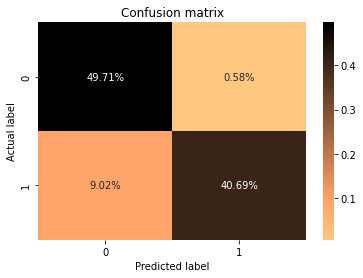

In [ ]:
cm_deci2 = metrics.confusion_matrix(y_test, y_pred_deci2)
sns.heatmap(cm_deci2/np.sum(cm_deci2), annot=True, fmt='.2%', cmap='copper_r')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

Confusion matrix shows that the actual negative values(false negative are predicted 49.71(previously 42.99%) correctly and actual positive values(true positive) are predicted 40.69(previously 44.15%) correctly.

On the other hand when the value was actual negative but the model predicted it to positive, this happened for 0.58 (previously 7.29%) and when the actual value was positive but the model predicted to be negative for 9.02 (previously 5.57%).


Report(Precision, Recall, F1-score, Accuracy)

In [ ]:
target_names = ['Died', 'Alive']
print(classification_report(y_test, y_pred_deci2, target_names=target_names))

              precision    recall  f1-score   support

        Died       0.85      0.99      0.91       262
       Alive       0.99      0.82      0.89       259

    accuracy                           0.90       521
   macro avg       0.92      0.90      0.90       521
weighted avg       0.92      0.90      0.90       521



Accuracy of the model is 90%(previously 87%) according to F1-score.

Precision: Model did predict 85%(previously 89%) correctly the people died who actually died. And 99% (previously 86%) correctly predicted as alive who actually survived.

Recall : This measures how many of the survived_victims the model is able to identify. Accordingly, our model identified 82% of them.

AUC

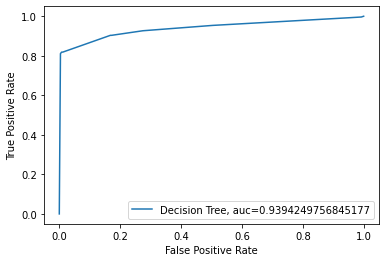

In [ ]:
y_pred_d_proba = deci2.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_d_proba)
auc = metrics.roc_auc_score(y_test, y_pred_d_proba)
plt.plot(fpr,tpr,label="Decision Tree, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

### The Random Forest Model
1. Importing model from library and creating model instance
2. Model fitting
3. Predictions
4. Feature importance
5. Confusion Matrix
6. Report(Precision, Recall, F1-score, Accuracy)
7. AUC

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=0)
#MODEL FITTING
r=rfc.fit(x_train,y_train)

Predictions

In [ ]:
y_pred_rfc=rfc.predict(x_test)
res_rfc = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_pred_rfc})
res_rfc

,Actual,Predicted
342,0,0
733,1,1
2322,1,1
166,1,0
1192,1,1
...,...,...
1370,0,0
2226,0,0
2520,0,0
24,1,1


Feature importance

In [ ]:
#weights of the coefficients and intercept
feature_imp = pd.Series(rfc.feature_importances_, index = x.columns).sort_values(ascending = False)
feature_imp

Hospitalised_yes             0.553631
Age                          0.142801
method_Hanging               0.106804
Education_iliterate          0.065143
Education_primary            0.037086
Occupation_others/unknown    0.018796
method_Other poison          0.015398
method_Poison unspec         0.012686
method_Pesticide             0.010274
Year                         0.005739
Month                        0.005236
Occupation_farming           0.004971
Sex_male                     0.003729
Occupation_professional      0.003364
method_Drowning              0.002801
Education_unknown            0.002656
Occupation_household         0.002374
method_unspecified           0.002217
method_Jumping               0.002186
Urban_yes                    0.000543
Education_Tertiary           0.000527
Occupation_retiree           0.000502
Occupation_student           0.000217
Occupation_worker            0.000216
Occupation_unemployed        0.000049
Occupation_others            0.000044
method_Other

Plotting the feature importance on basis of the above

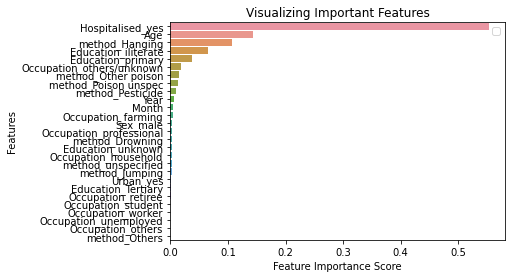

<Figure size 1152x720 with 0 Axes>

In [ ]:
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.legend()
plt. figure(figsize=(16,10))
plt.show()

Model Evaluation using Confusion Matrix

Text(0.5, 15.0, 'Predicted label')

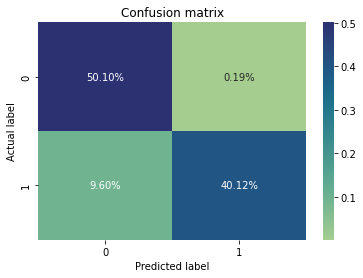

In [ ]:
cm_rfc = metrics.confusion_matrix(y_test, y_pred_rfc)
sns.heatmap(cm_rfc/np.sum(cm_rfc), annot=True, fmt='.2%', cmap='crest')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

Confusion matrix shows that the actual negative values(false negative are predicted 50.10% correctly and actual positive values(true positive) are predicted 40.12% correctly.

On the other hand when the value was actual negative but the model predicted it to positive, this happened for 0.19% and when the actual value was positive but the model predicted to be negative for 9.60%.

Report(Precision, Recall, F1-score, Accuracy)

In [ ]:
target_names = ['Died', 'Alive']
print(classification_report(y_test, y_pred_rfc, target_names=target_names))

              precision    recall  f1-score   support

        Died       0.84      1.00      0.91       262
       Alive       1.00      0.81      0.89       259

    accuracy                           0.90       521
   macro avg       0.92      0.90      0.90       521
weighted avg       0.92      0.90      0.90       521



Accuracy of the model is 90% according to F1-score.

Precision: Model did predict 84% correctly the people died who actually died. And 100% correctly predicted as alive who actually survived.

Recall : This measures how many of the survived_victims the model is able to identify. Accordingly, our model identified 81% of them.

AUC

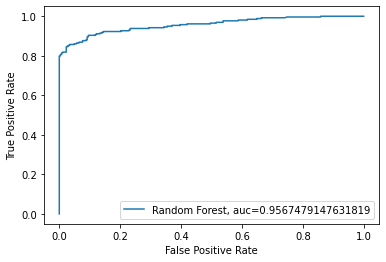

In [ ]:
y_pred_rfc_proba = rfc.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_rfc_proba)
auc = metrics.roc_auc_score(y_test, y_pred_rfc_proba)
plt.plot(fpr,tpr,label="Random Forest, auc="+str(auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc=4)
plt.show()

Modelling for new 'target':

In [ ]:
ds2=ds.copy()

In [ ]:
ds2=ds2.drop(['method_Drowning', 'method_Hanging','method_Jumping','method_Other poison','method_Others','method_Pesticide','method_Poison unspec','method_unspecified'], axis=1)

In [ ]:
ds2.nunique()

Hospitalised_yes              2
Died_yes                      2
Urban_yes                     2
Sex_male                      2
Education_Tertiary            2
Education_iliterate           2
Education_primary             2
Education_unknown             2
Occupation_farming            2
Occupation_household          2
Occupation_others             2
Occupation_others/unknown     2
Occupation_professional       2
Occupation_retiree            2
Occupation_student            2
Occupation_unemployed         2
Occupation_worker             2
Age                          88
Year                          3
Month                        12
dtype: int64

In [ ]:
ds2 = pd.concat([ds2, d['method']], axis=1)
ds2.nunique()

Hospitalised_yes              2
Died_yes                      2
Urban_yes                     2
Sex_male                      2
Education_Tertiary            2
Education_iliterate           2
Education_primary             2
Education_unknown             2
Occupation_farming            2
Occupation_household          2
Occupation_others             2
Occupation_others/unknown     2
Occupation_professional       2
Occupation_retiree            2
Occupation_student            2
Occupation_unemployed         2
Occupation_worker             2
Age                          88
Year                          3
Month                        12
method                        9
dtype: int64

In [ ]:
ds2.head()

,Hospitalised_yes,Died_yes,Urban_yes,Sex_male,Education_Tertiary,Education_iliterate,Education_primary,Education_unknown,Occupation_farming,Occupation_household,...,Occupation_others/unknown,Occupation_professional,Occupation_retiree,Occupation_student,Occupation_unemployed,Occupation_worker,Age,Year,Month,method
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,39.0,2010,12.0,Other poison
1,0,1,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,83.0,2009,3.0,Hanging
2,0,1,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,60.0,2010,2.0,Hanging
3,0,1,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,73.0,2011,1.0,Hanging
4,1,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,51.0,2009,8.0,Pesticide


Splitting dataset for training and testing with new target column

In [ ]:
#features of model:
xx=ds2.drop('method',axis=1)
yy=ds2['method']

# setting test data size 20%
xx_train, xx_test, yy_train, yy_test =train_test_split(xx,yy,test_size= 0.20, random_state=6)



#Logistic Regression

In [ ]:
logregg = LogisticRegression(random_state=6)

# fitting the model
logregg.fit(xx_train, yy_train)
#prediction
y_pred_logg = logregg.predict(xx_test)
y_pred_logg_train = logregg.predict(xx_train)
res_log = pd.DataFrame({'Actual' : yy_test, 'Predicted' : y_pred_logg})
res_log

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


,Actual,Predicted
342,Other poison,Pesticide
733,Hanging,Pesticide
2322,Hanging,Pesticide
166,Pesticide,Pesticide
1192,Pesticide,Pesticide
...,...,...
1370,Pesticide,Pesticide
2226,Pesticide,Pesticide
2520,Pesticide,Pesticide
24,Pesticide,Pesticide


In [ ]:
#accuracy
print("Accuracy:",metrics.accuracy_score(yy_test, y_pred_logg))

Accuracy: 0.727447216890595


# Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB

# creating model instance
nb = GaussianNB()
#Model fitting
nb.fit(xx_train, yy_train)

GaussianNB()

In [ ]:
y_pred_n = nb.predict(xx_test)
resn = pd.DataFrame({'Actual' : yy_test, 'Predicted' : y_pred_n})
resn

,Actual,Predicted
342,Other poison,unspecified
733,Hanging,Drowning
2322,Hanging,Drowning
166,Pesticide,unspecified
1192,Pesticide,Drowning
...,...,...
1370,Pesticide,unspecified
2226,Pesticide,unspecified
2520,Pesticide,unspecified
24,Pesticide,Drowning


In [ ]:
#Accuracy
print("Accuracy:",metrics.accuracy_score(yy_test, y_pred_n))

Accuracy: 0.028790786948176585


#Comparing the ROC Curve:

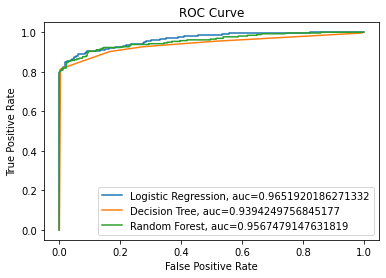

In [ ]:
plt.figure(0).clf()
y_pred_proba = logreg.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="Logistic Regression, auc="+str(auc))

y_pred_d_proba = decifit.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_d_proba)
auc = metrics.roc_auc_score(y_test, y_pred_d_proba)
plt.plot(fpr,tpr,label="Decision Tree, auc="+str(auc))

y_pred_rfc_proba = r.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_rfc_proba)
auc = metrics.roc_auc_score(y_test, y_pred_rfc_proba)
plt.plot(fpr,tpr,label="Random Forest, auc="+str(auc))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

Logistic regression has the most area under curve and provides highest accuracy.

#Predicting suicidal rates in future:

In [ ]:
z=ds.groupby('Year').Died_yes.sum()

In [ ]:
p=z.index.values.reshape(-1,1)
p

array([[2009],
       [2010],
       [2011]])

In [ ]:
q=z.values
q

array([326., 494., 443.])

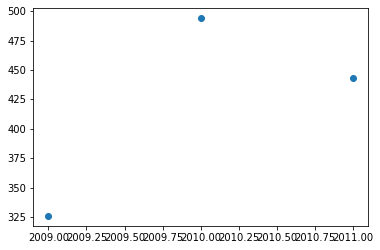

In [ ]:
plt.scatter(p,q)
plt.show()

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression() #instance
lr.fit(p,q) #model fit

LinearRegression()

In [ ]:
m=lr.coef_
m

array([58.5])

In [ ]:
c=lr.intercept_
c

-117163.99999999993

In [ ]:
q_pred=lr.predict(p)
q_pred

array([362.5, 421. , 479.5])

In [ ]:
q

array([326., 494., 443.])

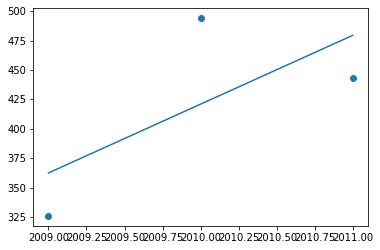

In [ ]:
plt.scatter(p,q)
plt.plot(p,q_pred)
plt.show()

In [ ]:
lr.score(p,q)*100

46.12818439142742

In [ ]:
#predicting deaths of 2012 using linear regression model
lr.predict([[2012]])

array([538.])

Polynomial regression

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
pr=PolynomialFeatures(degree=7) #instance
pr_x=pd.DataFrame(pr.fit_transform(p))
pr_x

,0,1,2,3,4,5,6,7
0,1.0,2009.0,4036081.0,8.108487e+09,1.628995e+13,3.272651e+16,6.574756e+19,1.320868e+23
1,1.0,2010.0,4040100.0,8.120601e+09,1.632241e+13,3.280804e+16,6.594416e+19,1.325478e+23
2,1.0,2011.0,4044121.0,8.132727e+09,1.635491e+13,3.288973e+16,6.614125e+19,1.330101e+23


In [ ]:
lreg=LinearRegression() #instance
lreg.fit(pr_x,q) #model fit

LinearRegression()

In [ ]:
m1=lreg.coef_
m1

array([ 3.16517106e-21,  4.39418233e-40,  2.28517637e-25,  5.51184468e-22,
        1.10788067e-18,  1.85569999e-15,  2.23797399e-12, -9.54233113e-16])

In [ ]:
c1=lreg.intercept_
c1

-21099418.569854125

In [ ]:
q1_pred=lreg.predict(pr_x)
q1_pred

array([326., 494., 443.])

In [ ]:
q

array([326., 494., 443.])

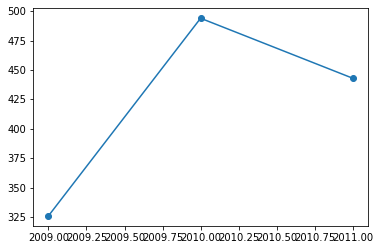

In [ ]:
plt.scatter(p,q)
plt.plot(p,q1_pred)
plt.show()

In [ ]:
lreg.score(pr_x,q)*100

100.0

In [ ]:
b=pr.fit_transform([[2012]])
b

array([[1.00000000e+00, 2.01200000e+03, 4.04814400e+06, 8.14486573e+09,
        1.63874698e+13, 3.29715893e+16, 6.63388377e+19, 1.33473742e+23]])

In [ ]:
lreg.predict(b)

array([171.90838476])

Logistic

In [ ]:
lg=LogisticRegression() #instance
lg.fit(p,q) #model fit
q_pred_g=lr.predict(p)
q_pred_g

array([362.5, 421. , 479.5])

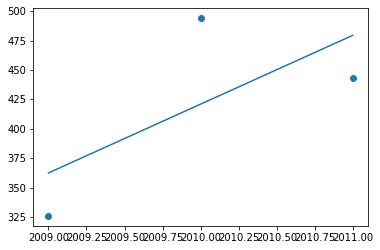

In [ ]:
plt.scatter(p,q)
plt.plot(p,q_pred_g)
plt.show()

In [ ]:
lg.score(p,q)*100
#predicting deaths of 2012 using logistic regression model
lg.predict([[2012]])

array([443.])